Used Datasets:

- Land Use (2018), Urban Atlas: 
https://land.copernicus.eu/en/products/urban-atlas?tab=land_coverland_use

- Building Height, Urban Atlas: 
https://land.copernicus.eu/en/products/urban-atlas?tab=building_height

- Public Housing, Madrid City Council: 
https://datos.madrid.es/portal/site/egob/menuitem.c05c1f754a33a9fbe4b2e4b284f1a5a0/?vgnextoid=73fd3e57474bb510VgnVCM2000001f4a900aRCRD&vgnextchannel=374512b9ace9f310VgnVCM100000171f5a0aRCRD&vgnextfmt=default

- Rent Stats (2023), Madrid City Council:
https://www.madrid.es/portales/munimadrid/es/Inicio/El-Ayuntamiento/Estadistica/Areas-de-informacion-estadistica/Edificacion-y-vivienda/Mercado-de-la-vivienda/Sistema-estatal-de-indices-de-referencia-del-precio-del-alquiler-de-viviendas/?vgnextfmt=default&vgnextoid=a386d9a1fe930910VgnVCM2000001f4a900aRCRD&vgnextchannel=22613c7ea422a210VgnVCM1000000b205a0aRCRD

- Public Transportation Usage (2018), Kaggle:
https://www.kaggle.com/datasets/dataguapa/madrid-public-transportation-data-2018

- Travel Behavior and Climatic Data (2018), Kaggle:
https://www.kaggle.com/datasets/dataguapa/madrid-travel-behavior-2018/data


# 0. Imports and Preparation

In [194]:
!pip install geopandas shapely pyproj fiona rtree rasterio rasterstats osmnx contextily openpyxl

In [195]:
# === Core Data Science ===
import pandas as pd
import numpy as np

# === Spatial / Geospatial ===
import geopandas as gpd
import osmnx as ox
from shapely.geometry import box, Point, Polygon
from shapely.ops import unary_union

# === Raster Handling ===
import rasterio
from rasterio import features
from rasterio.mask import mask

# Zonal statistics for height raster → grid
from rasterstats import zonal_stats

# === File & System ===
import os
import unicodedata

# === Plotting ===
import matplotlib.pyplot as plt
import contextily as cx

# === Warnings Cleanup ===
import warnings
warnings.filterwarnings("ignore")

In [196]:
RAW_DIR = "data/raw"
PROC_DIR = "data/processed"
os.makedirs(PROC_DIR, exist_ok=True)

In [197]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)
pd.set_option("display.expand_frame_repr", False)

# 1. Creating Data Layers


This notebook documents the construction of a combined, grid-based dataset for the city of Madrid. The analysis begins by defining a common spatial reference framework and incrementally integrating multiple urban data layers, including spatial, infrastructural, and environmental variables. Each dataset is preprocessed individually before being aligned to the shared grid, allowing differences in resolution, coverage, and structure to be made explicit.

The purpose of this process is not to optimise or evaluate densification outcomes, but to examine how available urban data can be combined, transformed, and interpreted at a city scale. By constructing the dataset step by step, the analysis foregrounds the practical decisions involved in preprocessing, aggregation, and spatial alignment, and highlights how these choices shape what becomes visible in subsequent analysis.


### Create Grid of Madrid

A uniform spatial grid is created to establish a common reference framework for all subsequent data layers. This grid defines the spatial resolution of the analysis and enables heterogeneous datasets to be aligned, aggregated, and compared consistently across the EDA.

The grid is clipped to the administrative boundary of Madrid to ensure that all subsequent analyses are spatially constrained to the defined area.

In [198]:
# Get Madrid municipal boundary via OSMnx

# Use OSMnx to geocode the Madrid boundary
madrid = ox.geocode_to_gdf("Madrid, Spain")

print("Original CRS:", madrid.crs)
# Project to UTM (meters) for grid creation
madrid_utm = madrid.to_crs(25830)   # ETRS89 / UTM zone 30N (covers Madrid)
poly = madrid_utm.geometry.iloc[0]

print("Projected CRS:", madrid_utm.crs)
print("Municipality area (km²):", round(poly.area / 1e6, 1))

Original CRS: epsg:4326
Projected CRS: EPSG:25830
Municipality area (km²): 604.3


In [199]:
# Create a 250 m grid covering the municipal polygon

cell_size = 250  # meters

xmin, ymin, xmax, ymax = poly.bounds
cells = []

xs = np.arange(xmin, xmax, cell_size)
ys = np.arange(ymin, ymax, cell_size)

for x in xs:
    for y in ys:
        cell = box(x, y, x + cell_size, y + cell_size)
        if cell.intersects(poly):  # keep only cells that touch Madrid
            cells.append(cell)

grid = gpd.GeoDataFrame({"geometry": cells}, crs=madrid_utm.crs)
grid["cell_id"] = range(len(grid))

print("✅ Grid created with", len(grid), "cells")

✅ Grid created with 10100 cells


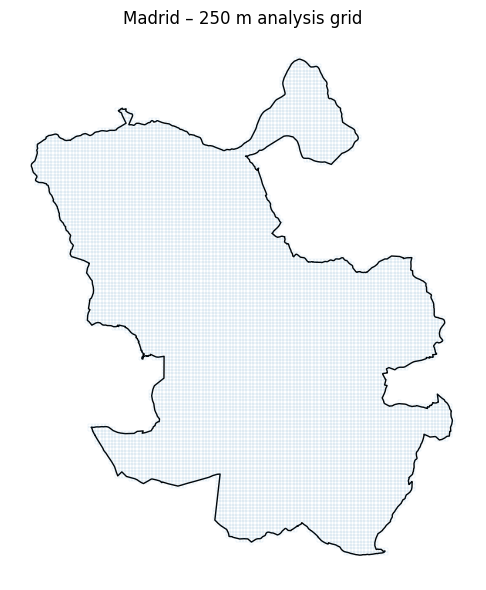

In [200]:
# Quick check if the grid looks good
fig, ax = plt.subplots(figsize=(6, 6))
madrid_utm.boundary.plot(ax=ax, color="black", linewidth=1)
grid.boundary.plot(ax=ax, linewidth=0.1, alpha=0.5)
ax.set_title("Madrid – 250 m analysis grid")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [201]:
# Save grid for later steps
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m.gpkg")
grid.to_file(grid_path, layer="grid_250m", driver="GPKG")

print("Saved grid to:", grid_path)

Saved grid to: data/processed/madrid_grid_250m.gpkg


### Add Land Use Data (2018)

This step integrates the first urban data layer into the grid. The dataset is preprocessed and spatially joined to the grid, making differences in coverage and resolution explicit.

In [202]:
# Load the grid
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m")
print("Grid CRS:", grid.crs)
print("Grid cells:", len(grid))

# Load Urban Atlas land use (2018)
lu_path = os.path.join(RAW_DIR, "urban_atlas_lu_2018.gpkg")  # <-- change filename if needed
lu = gpd.read_file(lu_path)
print("Land use CRS:", lu.crs)
print("Land use columns:", lu.columns.tolist())

Grid CRS: EPSG:25830
Grid cells: 10100
Land use CRS: EPSG:3035
Land use columns: ['country', 'fua_name', 'fua_code', 'code_2018', 'class_2018', 'prod_date', 'identifier', 'perimeter', 'area', 'comment', 'Pop2018', 'geometry']


Every geospatial dataset has a coordinate system, called a **CRS** (Coordinate Reference System).
If two datasets use different coordinate systems, then:

- they won’t overlap correctly
- spatial join won’t work
- “within” checks will fail
- distances will be wrong

The Madrid grid uses meters (EPSG:25830).
The land-use file might use latitude/longitude degrees (EPSG:4326) or something else.

So before I can overlay the datasets, I must put them into the same coordinate system.

In [203]:
# Reproject land use to match grid (should be EPSG:25830)
if lu.crs != grid.crs:
    lu = lu.to_crs(grid.crs)

print("Land use CRS after reprojection:", lu.crs)

Land use CRS after reprojection: EPSG:25830


At this point, I have two separate datasets:

- A 250 m × 250 m grid covering the whole city of Madrid 
→ this is my common spatial unit for all analyses in the project
- Urban Atlas land-use polygons (2018)
→ these polygons describe how land is used (e.g. residential, industrial, green areas)

The goal of this step is to connect these two datasets, so that:

Each grid cell gets assigned one land-use category

This allows me to later:

- compare different parts of the city
- aggregate other datasets to the same grid

Instead of trying to overlap entire grid cells with land-use polygons (which is slow and complex), I use a centroid-based approach:

1) For each grid cell, I calculate its centroid

- The centroid is simply the point at the center of the square.

2) I check which land-use polygon contains this centroid point

- If the centroid falls inside a residential polygon, the grid cell is considered residential.
- If it falls inside a green area polygon, the grid cell is considered green, etc.

In [204]:
# Make centroids of grid cells
grid_centroids = grid.copy()
grid_centroids["geometry"] = grid_centroids.geometry.centroid

# Spatial join: which land-use polygon contains each centroid?
cols_lu = ["code_2018", "class_2018", "geometry"]

joined = gpd.sjoin(
    grid_centroids[["cell_id", "geometry"]],
    lu[cols_lu],
    how="left",
    predicate="within"
)

print("Joined rows:", len(joined))
print(joined.head())

Joined rows: 10100
   cell_id                        geometry  index_right code_2018                                                    class_2018
0        0  POINT (424879.339 4490931.475)        57998     11220  Discontinuous medium density urban fabric (S.L. : 30% - 50%)
1        1  POINT (424879.339 4491181.475)        87592     23000                                                      Pastures
2        2  POINT (424879.339 4491431.475)        87592     23000                                                      Pastures
3        3  POINT (424879.339 4491681.475)        87592     23000                                                      Pastures
4        4  POINT (424879.339 4491931.475)        17086     11210          Discontinuous dense urban fabric (S.L. : 50% -  80%)


In [205]:
# Drop existing land-use columns if they exist, to prevent duplicates on re-run
grid = grid.drop(columns=["lu_2018_code", "lu_2018_class"], errors="ignore")

# Merge land-use attributes back to original grid cells
grid = grid.merge(
    joined[["cell_id", "code_2018", "class_2018"]],
    on="cell_id",
    how="left"
)

# 4) Rename for clarity
grid = grid.rename(columns={
    "code_2018": "lu_2018_code",
    "class_2018": "lu_2018_class"
})

grid[["cell_id", "lu_2018_code", "lu_2018_class"]].head()
grid["lu_2018_class"].value_counts().head()

lu_2018_class
Herbaceous vegetation associations (natural grassland, moors...)    2997
Green urban areas                                                   1023
Industrial, commercial, public, military and private units           875
Pastures                                                             760
Other roads and associated land                                      745
Name: count, dtype: int64

Example output:

After assigning land-use information, each grid cell contains the following attributes:

| cell_id | lu_2018_code | lu_2018_class |
|--------:|-------------:|---------------|
| 1023 | 11100 | Continuous urban fabric |
| 1024 | 14100 | Green urban areas |
| 1025 | 12100 | Industrial / commercial units |

**Interpretation:**

- **Cell 1023** is mainly residential.  
- **Cell 1024** is mainly green or open space.  
- **Cell 1025** is mainly industrial or commercial.

Each grid cell is therefore assigned a *dominant land-use category*, which can be used for exploratory data analysis, visualization, and later modeling.

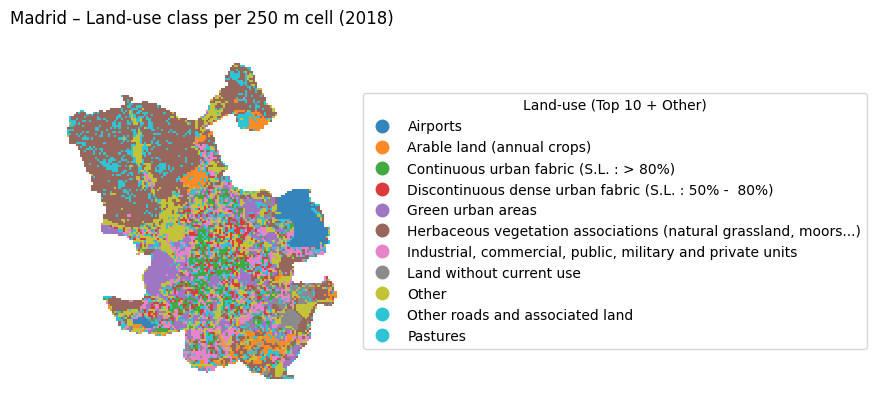

In [206]:
# Quick visualization of the land-use distribution
TOP_N = 10  # try 8–12

# simplify classes
top = grid["lu_2018_class"].value_counts().head(TOP_N).index
grid["lu_2018_class_simplified"] = grid["lu_2018_class"].where(grid["lu_2018_class"].isin(top), "Other")

fig, ax = plt.subplots(figsize=(8, 8))

grid.plot(
    ax=ax,
    column="lu_2018_class_simplified",
    categorical=True,
    legend=True,
    linewidth=0.0,
    alpha=0.9,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5),
        "title": f"Land-use (Top {TOP_N} + Other)",
        "frameon": True
    }
)

ax.set_axis_off()
ax.set_title("Madrid – Land-use class per 250 m cell (2018)")
plt.tight_layout()
plt.show()

In [207]:
# Save the grid with land-use information
out_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu.gpkg")
grid.to_file(out_path, layer="grid_250m_lu", driver="GPKG")
print("Saved:", out_path)

Saved: data/processed/madrid_grid_250m_lu.gpkg


### Add Building Height Data

The next data layer is preprocessed and aligned to the grid. Each layer is added independently to preserve transparency about how individual variables contribute to the combined dataset.

The building height dataset is a raster (10 m pixels).
The Madrid grid is a vector (250 m squares).
I want to summarize the raster values inside each grid cell so that each cell gets height metrics like:

`height_mean` → average building height (meters)

`height_max` → maximum building height (meters)

In [208]:
# Load the grid with land-use information (output of previous step)
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m_lu")

print("Grid CRS:", grid.crs)
print("Grid cells:", len(grid))

# Load the Urban Atlas building height raster
height_path = os.path.join(RAW_DIR, "urban_atlas_height.tif")

with rasterio.open(height_path) as src:
    print("Height raster CRS:", src.crs)
    print("Raster resolution:", src.res)
    print("Raster NoData value:", src.nodata)
    raster_crs = src.crs
    raster_nodata = src.nodata

Grid CRS: EPSG:25830
Grid cells: 10100
Height raster CRS: EPSG:3035
Raster resolution: (10.0, 10.0)
Raster NoData value: 65535.0


Just like with land use, raster + vector data must be in the same coordinate system, otherwise the grid cells will not align correctly with raster pixels.

So I ensure the grid is in the raster CRS:

In [209]:
# Reproject grid to match raster CRS
if grid.crs != raster_crs:
    grid = grid.to_crs(raster_crs)

print("Grid CRS after CRS check:", grid.crs)

Grid CRS after CRS check: PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]


I now calculate statistics of the raster inside each grid cell.

This uses `zonal_stats`, which means:

*“Take all raster pixels that fall inside each grid cell polygon, and compute summary values.”*

I compute mean and max:

In [210]:
# Compute mean and max building height for each grid cell
height_stats = zonal_stats(
    grid.geometry,
    height_path,
    stats=["mean", "max"],
    nodata=raster_nodata
)

# Add results as new columns
grid["height_mean"] = [s["mean"] for s in height_stats]
grid["height_max"]  = [s["max"]  for s in height_stats]

print(grid[["cell_id", "height_mean", "height_max"]].head())
grid[["height_mean", "height_max"]].describe()

   cell_id  height_mean  height_max
0        0        5.875         8.0
1        1        5.000         5.0
2        2          NaN         NaN
3        3          NaN         NaN
4        4          NaN         NaN


,height_mean,height_max
count,4511.000000,4511.000000
mean,13.112925,25.951230
std,7.309244,16.489917
min,3.000000,3.000000
25%,7.834388,14.000000
50%,11.690751,24.000000
75%,16.915679,34.000000
max,236.828571,250.000000


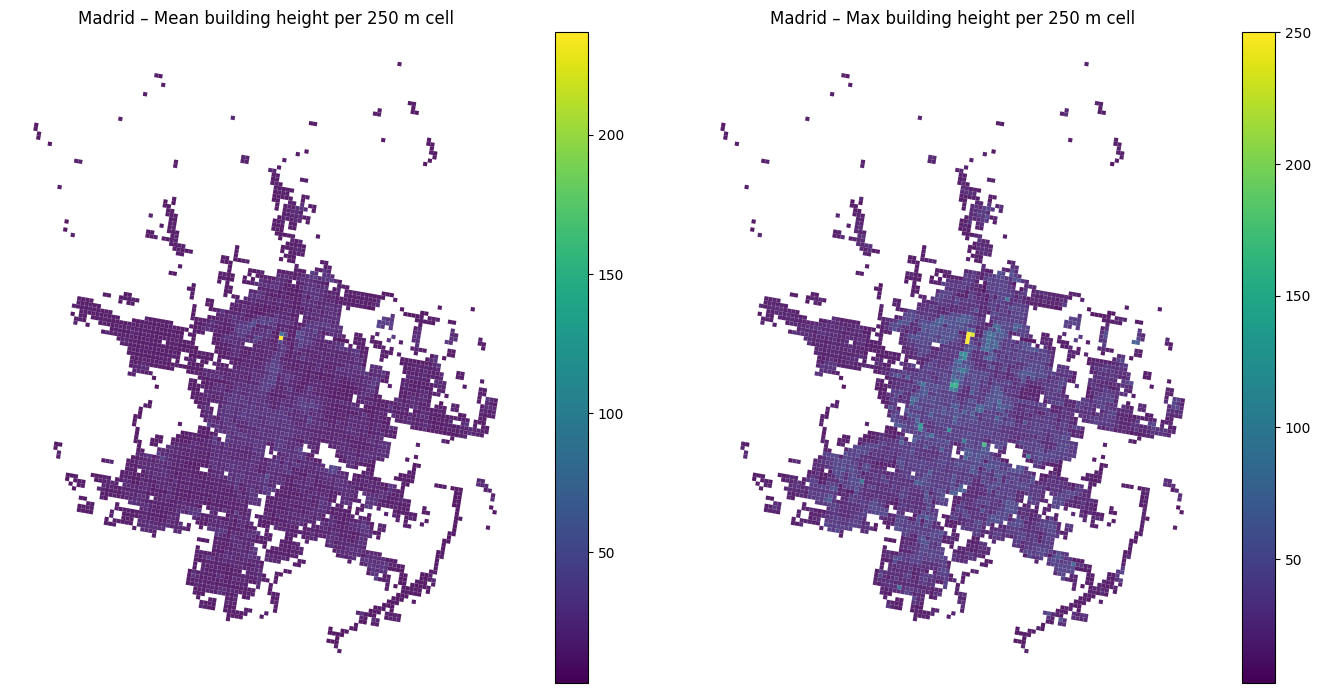

In [211]:
# Quick visualization of height distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

grid.plot(
    ax=ax[0],
    column="height_mean",
    legend=True,
    linewidth=0,
    alpha=0.9
)
ax[0].set_title("Madrid – Mean building height per 250 m cell")
ax[0].set_axis_off()

grid.plot(
    ax=ax[1],
    column="height_max",
    legend=True,
    linewidth=0,
    alpha=0.9
)
ax[1].set_title("Madrid – Max building height per 250 m cell")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

How to interpret the colors:

- Dark / purple cells → low average height
    - low-rise housing
    - detached or semi-detached buildings
    - green areas / non-built-up areas (many 0 or near-0 pixels)

- Lighter / greenish cells → higher average height
    -dense urban fabric
    -apartment blocks
    -mixed-use areas with mid-rise buildings

Why most of Madrid looks dark:

- Large parts of the city include:
    - parks
    - roads
    - low-rise residential

- Averaging over 250 m cells “dilutes” tall buildings unless there are many of them.

In [212]:
# Save the grid with height + land-use information
out_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height.gpkg")
grid.to_file(out_path, layer="grid_250m_lu_height", driver="GPKG")

print("Saved:", out_path)

Saved: data/processed/madrid_grid_250m_lu_height.gpkg


### Add Public Transportation Data

The next data layer is preprocessed and aligned to the grid. Each layer is added independently to preserve transparency about how individual variables contribute to the combined dataset.

Public transport stops represent accessibility, which is a key factor for:

- densification potential
- housing attractiveness
- mobility and quality of life

I extract public transport stop/station locations from OpenStreetMap for Madrid, then assign them to the 250 m grid so each cell has a count.

In [213]:
# Load the grid with land use + height
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m_lu_height")

print("Grid CRS:", grid.crs)
print("Grid cells:", len(grid))

Grid CRS: EPSG:3035
Grid cells: 10100


The grid CRS is different again, so we need to have the same one before we can join the data.

In [214]:
# Download public transport features from OpenStreetMap
# Querying a few common OSM tags that represent stops/stations.
# Note: OSM tagging is not perfect; this is an EDA-friendly approximation.

place = "Madrid, Spain"

tags_stops = {
    "highway": "bus_stop", # bus stops
    "public_transport": ["platform", "stop_position"],  # generic PT stops/platforms
    "railway": ["station", "tram_stop", "subway_entrance"]  # rail/tram/metro entrances
}

# OSMnx v2 uses features_from_place
pt = ox.features_from_place(place, tags=tags_stops)

print("✅ Raw OSM transport features:", len(pt))
print("Geometry types:", pt.geom_type.value_counts())
print("Columns:", pt.columns.tolist()[:20], "...")
pt.head()

✅ Raw OSM transport features: 12225
Geometry types: Point         11916
Polygon         226
LineString       83
Name: count, dtype: int64
Columns: ['geometry', 'bus', 'public_transport', 'covered', 'fare_area', 'name', 'operator', 'railway', 'subway', 'wheelchair', 'bench', 'bin', 'highway', 'lit', 'shelter', 'tactile_paving', 'source', 'ref', 'colour', 'network'] ...


geometry  bus public_transport covered fare_area                    name         operator railway subway wheelchair bench  bin highway  lit shelter tactile_paving source  ref colour network toilets:wheelchair light_rail train wikidata wikipedia layer source:name wheelchair:description station addr:city old_name  url source:date bicycle air_conditioning contact:website level network:wikidata operator:wikidata platforms toilets:menstrual_products website crossing button_operated traffic_signals:sound traffic_signals:vibration check_date:wheelchair name:ar name:es check_date:shelter network:short source:website route_ref internet_access type created_by disabled fixme alt_name access door entrance indoor image start_date wikimedia_commons ref:signed building:levels postal_code note operator:short survey:date description elevator tunnel departures_board opening_hours addr:postcode name:en name:pt check_date:bench not:network:wikidata tram name:ru check_date:tactile_paving kerb kerb:approach_aid passenger_information_display passenger_information_display:speech_output disused:highway uic_name check_date:bin name:zh surface information information:voice tourism craft check_date:lit old_ref local_ref designation backrest material seats construction crossing:markings ramp addr:street addr:housenumber fare_zone crossing:island mapillary source:wheelchair width check_date public_transport:version intercambiador nohousenumber contact:url location defibrillator:location emergency source_url usage railway:ref barrier stop_id zone iata monorail email step_count name:tr building foot landuse area announcement roof:levels roof:colour height building:material disused:public_transport roof:shape
element id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
node    20953215    POINT (-3.72099 40.421)  yes    stop_position     NaN       NaN                     NaN              NaN     NaN    NaN        NaN   NaN  NaN     NaN  NaN     NaN            NaN    NaN  NaN    NaN     NaN                NaN        NaN   NaN      NaN       NaN   NaN         NaN                    NaN     NaN       NaN      NaN  NaN         NaN     NaN              NaN             NaN   NaN              NaN               NaN       NaN                        NaN     NaN      NaN             NaN                   NaN               

OSM can return polygons/lines sometimes (e.g., station areas).
For counting stops per cell, we want points.

If we get polygons, we convert them to centroids.

In [215]:
# Convert everything to points for consistent counting
pt = pt.copy()

# If geometry isn't point, convert to centroid
pt["geometry"] = pt.geometry.apply(
    lambda g: g if g.geom_type == "Point" else g.centroid
)

# Ensure GeoDataFrame stays valid
pt = gpd.GeoDataFrame(pt, geometry="geometry", crs=pt.crs)

print("✅ After point conversion:", len(pt))
print("Geometry types now:", pt.geom_type.value_counts())

✅ After point conversion: 12225
Geometry types now: Point    12225
Name: count, dtype: int64


Just like before, I need both datasets to be in the same CRS.

In [216]:
# Ensure PT is in the same CRS as the grid
pt = pt.to_crs(grid.crs)

# Spatial join: which transport points fall into which grid cell?
pt_joined = gpd.sjoin(
    pt[["geometry"]],
    grid[["cell_id", "geometry"]],
    how="left",
    predicate="within"
)

print("Joined rows:", len(pt_joined))
pt_joined.head()

Joined rows: 12225


geometry  index_right  cell_id
element id                                                             
node    20953215   POINT (3158027.95 2030574.241)         4009     4009
        20962897   POINT (3167165.268 2029069.66)         8185     8185
        21473049  POINT (3157172.426 2032163.381)         3485     3485
        21627147  POINT (3160489.103 2028623.045)         5302     5302
        21696626  POINT (3153933.196 2027381.406)         2516     2516

Now I count how many transport points are inside each cell.

*Note: When the cell below gives an error when executed, try running every cell of the "Add Public Transportation Data" again.*

In [217]:
# Count points per grid cell
pt_counts = (
    pt_joined
    .groupby("cell_id")
    .size()
    .rename("pt_stop_count")
)

grid = grid.merge(pt_counts, on="cell_id", how="left")
grid["pt_stop_count"] = grid["pt_stop_count"].fillna(0).astype(int)

# Define what "good access" means
THRESHOLD = 3

grid["pt_access_good"] = grid["pt_stop_count"] >= THRESHOLD
grid["pt_access_good"].value_counts()

grid[["cell_id", "pt_stop_count"]].head()
grid["pt_stop_count"].describe()

count    10100.000000
mean         1.210396
std          3.300597
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         70.000000
Name: pt_stop_count, dtype: float64

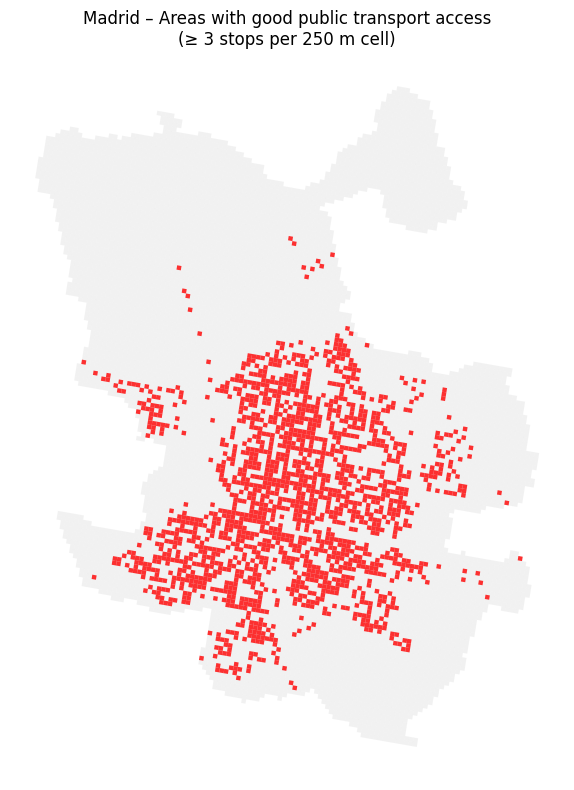

In [218]:
# Quick visualization of stop density
fig, ax = plt.subplots(figsize=(8, 8))

grid.plot(
    ax=ax,
    color="lightgrey",
    linewidth=0,
    alpha=0.3
)

grid[grid["pt_access_good"]].plot(
    ax=ax,
    color="red",
    linewidth=0,
    alpha=0.8
)

ax.set_axis_off()
ax.set_title("Madrid – Areas with good public transport access\n(≥ 3 stops per 250 m cell)")
plt.tight_layout()
plt.show()


In [219]:
# Save the grid with height + land-use + public transport information
out_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport.gpkg")
grid.to_file(out_path, layer="grid_250m_lu_height_transport", driver="GPKG")

print("Saved:", out_path)

Saved: data/processed/madrid_grid_250m_lu_height_transport.gpkg


### Add Rent Statistics Data

The next data layer is preprocessed and aligned to the grid. Each layer is added independently to preserve transparency about how individual variables contribute to the combined dataset.

The rent dataset contains housing market indicators (average rent, surface, number of dwellings) at the municipal district level.

Because rent data is not available per address or building, I assign district-level rent values to all grid cells inside that district.

In [332]:
# Load the grid with land use + height + transport
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m_lu_height_transport").copy(deep=True)
assert len(grid) == grid["cell_id"].nunique(), "❌ DUPLICATE CELL_ID AFTER LOADING GRID FOR RENT DATA"

print("Grid cells:", len(grid))

# Load rent statistics (Excel)
rent_path = os.path.join(RAW_DIR, "Rent_stats_2023.xlsx")
rent = pd.read_excel(rent_path, header=9)

print("Rent data columns:")
print(rent.columns)
rent.head()

Grid cells: 10100
Rent data columns:
Index(['Unnamed: 0', 'Unnamed: 1', 'Nº viviendas', 'Viviendas colectivas', 'Viviendas unifamiliares', 'Mediana',
       'Percentil 25', 'Percentil 75', 'Mediana.1', 'Percentil 25.1', 'Percentil 75.1', 'Mediana.2', 'Percentil 25.2',
       'Percentil 75.2', 'Mediana.3', 'Percentil 25.3', 'Percentil 75.3', 'Mediana.4', 'Percentil 25.4',
       'Percentil 75.4', 'Mediana.5', 'Percentil 25.5', 'Percentil 75.5'],
      dtype='object')


,Unnamed: 0,Unnamed: 1,Nº viviendas,Viviendas colectivas,Viviendas unifamiliares,Mediana,Percentil 25,Percentil 75,Mediana.1,Percentil 25.1,Percentil 75.1,Mediana.2,Percentil 25.2,Percentil 75.2,Mediana.3,Percentil 25.3,Percentil 75.3,Mediana.4,Percentil 25.4,Percentil 75.4,Mediana.5,Percentil 25.5,Percentil 75.5
0,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Ciudad de Madrid,294408.0,291225.0,3183.0,66,52,84,13.304348,10.563380,16.923077,825.0,669.166667,1100.0,176.0,82.0,277.0,11.300613,8.306789,14.736176,1241.666667,715.686275,2416.75
2,Ene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Feb,01 - Centro,20393.0,20385.0,8.0,55,41,77,16.774194,13.330071,20.503201,900.0,713.480000,1200.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00
4,Mar,02 - Arganzuela,16001.0,15997.0,4.0,63,47,81,15.189873,12.622596,18.124915,900.0,738.678571,1150.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00


Only the first column `mediana` is chosen. Combined with the district I will use this information and translate it to the city grid.

In [333]:
# pick district column = first non-empty text-like column
district_col = rent.columns[1]

# pick first median column (collective rent €/m²/month) = first column named like "mediana"
median_cols = [c for c in rent.columns if str(c).lower().startswith("mediana")]

print("District col guess:", district_col)
print("Median cols:", median_cols)

rent_clean = rent[[district_col, median_cols[0]]].copy()
rent_clean = rent_clean.rename(columns={
    district_col: "district_name",
    median_cols[0]: "rent_median_m2_2023"
})
rent_clean["rent_median_m2_2023"] = pd.to_numeric(rent_clean["rent_median_m2_2023"], errors="coerce")


District col guess: Unnamed: 1
Median cols: ['Mediana', 'Mediana.1', 'Mediana.2', 'Mediana.3', 'Mediana.4', 'Mediana.5']


In order to properly join the rent of the districts with OSM data, I need to clean it first.

In [334]:
# Drop empty rows with NaN
rent_clean = rent_clean.dropna(subset=["district_name"]).copy()

# Keep only rows that look like "01 - Centro"
rent_clean = rent_clean[rent_clean["district_name"].str.contains("-", regex=False)]

print("Remaining rows:", len(rent_clean))

# Remove "01 - " prefix
rent_clean["district_name"] = (
    rent_clean["district_name"]
    .str.split(" - ", n=1)
    .str[1]
    .str.upper()
    .str.strip()
)

rent_clean.head()

Remaining rows: 21


,district_name,rent_median_m2_2023
3,CENTRO,55.0
4,ARGANZUELA,63.0
5,RETIRO,72.0
7,SALAMANCA,65.0
8,CHAMARTÍN,68.0


District names may contain accents (e.g. Chamartín) or slightly different formatting in different sources.
To match names reliably, I create a normalized key for both datasets:

- remove accents
- make uppercase
- remove extra spaces

In [335]:
# Normalize strings (remove accents, uppercase, trim) 
def normalize(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    return s.upper().strip()

# Create a normalized key in rent table
rent_clean = rent_clean.copy()
rent_clean["district_key"] = rent_clean["district_name"].apply(normalize)

# Manual fixes for known name issues (typos / naming differences)
rent_clean["district_key"] = rent_clean["district_key"].replace({
    "CARANBANCHEL": "CARABANCHEL",
    "SAN BLAS": "SAN BLAS - CANILLEJAS"
})

print("Rent districts:", len(rent_clean))
print(rent_clean[["district_name", "district_key", "rent_median_m2_2023"]].head())

Rent districts: 21
  district_name district_key  rent_median_m2_2023
3        CENTRO       CENTRO                 55.0
4    ARGANZUELA   ARGANZUELA                 63.0
5        RETIRO       RETIRO                 72.0
7     SALAMANCA    SALAMANCA                 65.0
8     CHAMARTÍN    CHAMARTIN                 68.0


I now load district boundary polygons from OpenStreetMap.
These provide the geographic shapes needed to assign rent values spatially.

In [336]:
districts = ox.features_from_place(
    "Madrid, Spain",
    tags={"boundary": "administrative", "admin_level": "8"}
)

# Keep only polygon geometries
districts = districts[districts.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

# Define your desired list of normalized district names
desired_district_keys_hardcoded = [
    "CENTRO", "ARGANZUELA", "RETIRO", "SALAMANCA", "CHAMARTIN",
    "TETUAN", "CHAMBERI", "FUENCARRAL-EL PARDO", "MONCLOA-ARAVACA", "LATINA",
    "CARABANCHEL", "USERA", "PUENTE DE VALLECAS", "MORATALAZ", "CIUDAD LINEAL",
    "HORTALEZA", "VILLAVERDE", "VILLA DE VALLECAS", "VICALVARO", "SAN BLAS - CANILLEJAS",
    "BARAJAS"
]

# Create a normalized 'district_key' in the districts GeoDataFrame for matching
districts["district_key"] = districts["name"].apply(normalize)

# Filter districts to keep only those matching your hardcoded list
districts = districts[districts["district_key"].isin(desired_district_keys_hardcoded)].copy()

print("Filtered OSM district polygons after hardcoded matching:", len(districts))
districts[["name", "district_key"]].head()

Filtered OSM district polygons after hardcoded matching: 21


name        district_key
element  id                                            
relation 349469               Usera               USERA
         349470          Villaverde          VILLAVERDE
         349485   Villa de Vallecas   VILLA DE VALLECAS
         354080  Puente de Vallecas  PUENTE DE VALLECAS
         354223           Moratalaz           MORATALAZ

In [337]:
# Define your desired list of normalized district names
# Ensure these names are consistent with the 'normalize' function defined in Cell 55
desired_districts = [
    "CENTRO", "ARGANZUELA", "RETIRO", "SALAMANCA", "CHAMARTIN",
    "TETUAN", "CHAMBERI", "FUENCARRAL-EL PARDO", "MONCLOA-ARAVACA", "LATINA",
    "CARABANCHEL", "USERA", "PUENTE DE VALLECAS", "MORATALAZ", "CIUDAD LINEAL",
    "HORTALEZA", "VILLAVERDE", "VILLA DE VALLECAS", "VICALVARO", "SAN BLAS - CANILLEJAS",
    "BARAJAS"
]

# Ensure 'district_key' is present in 'districts' for matching
# This line applies the 'normalize' function (defined in Cell 55) to the 'name' column
districts["district_key"] = districts["name"].apply(normalize)

# Filter districts to keep only those matching your hardcoded list
districts = districts[districts["district_key"].isin(desired_district_keys_hardcoded)].copy()

print("Filtered OSM district polygons using hardcoded list:", len(districts))

Filtered OSM district polygons using hardcoded list: 21


I now create the same standardized `district_key` in the polygon dataset and check how many district names match.

In [338]:
districts["district_key"] = districts["name"].apply(normalize)

matches = set(rent_clean["district_key"]) & set(districts["district_key"])
print("Matching district names:", len(matches), "out of", len(rent_clean))

# Optional: list unmatched rent districts (if any)
missing = sorted(set(rent_clean["district_key"]) - set(districts["district_key"]))
print("Rent districts not found in OSM (if any):", missing)

Matching district names: 20 out of 21
Rent districts not found in OSM (if any): ['SAN BLAS-CANILLEJAS']


Now I attach the rent value to each district polygon.

In [339]:
districts_joined = districts.merge(
    rent_clean[["district_key", "rent_median_m2_2023"]],
    on="district_key",
    how="inner"   # keep only matching districts
)

print("Districts after join:", len(districts_joined))
print("Missing rent values:", districts_joined["rent_median_m2_2023"].isna().sum())

districts_joined[["name", "rent_median_m2_2023"]].head()

Districts after join: 20
Missing rent values: 0


,name,rent_median_m2_2023
0,Usera,66.0
1,Villaverde,66.0
2,Villa de Vallecas,71.0
3,Puente de Vallecas,61.0
4,Moratalaz,70.0


I now distribute district rent values to the analysis grid.

Because a grid cell is a square polygon, I use a centroid-based assignment again:

- compute the centroid of each grid cell
- find the district polygon that contains the centroid
- assign that district’s rent value to the grid cell

In [340]:
# Load the current grid (land use + height + transport)
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m_lu_height_transport").copy(deep=True)
assert len(grid) == grid["cell_id"].nunique(), "❌ DUPLICATE CELL_ID AFTER INITIAL GRID LOAD IN EMVS CELL"

# Reproject districts to match grid CRS
districts_joined = districts_joined.to_crs(grid.crs)
assert len(grid) == grid["cell_id"].nunique(), "❌ DUPLICATE CELL_ID AFTER INITIAL GRID LOAD IN EMVS CELL"

# Create grid centroids
grid_centroids = grid.copy()
grid_centroids["geometry"] = grid_centroids.geometry.centroid

# Spatial join: assign each grid cell to a district rent value
grid_rent = gpd.sjoin(
    grid_centroids[["cell_id", "geometry"]],
    districts_joined[["rent_median_m2_2023", "geometry"]],
    how="left",
    predicate="within"
)

# Merge rent values back to the grid
grid = grid.merge(
    grid_rent[["cell_id", "rent_median_m2_2023"]],
    on="cell_id",
    how="left"
)
assert len(grid) == grid["cell_id"].nunique(), "❌ DUPLICATE CELL_ID AFTER MERGING RENT DATA"

grid["rent_median_m2_2023"].describe()

count    9313.000000
mean       72.984001
std         5.852833
min        55.000000
25%        69.000000
50%        77.000000
75%        77.000000
max        80.000000
Name: rent_median_m2_2023, dtype: float64

Each grid cell now contains a district-level rent value:

- grid cells inside the same district share the same rent value
- sharp borders between districts are expected and reflect the original data resolution

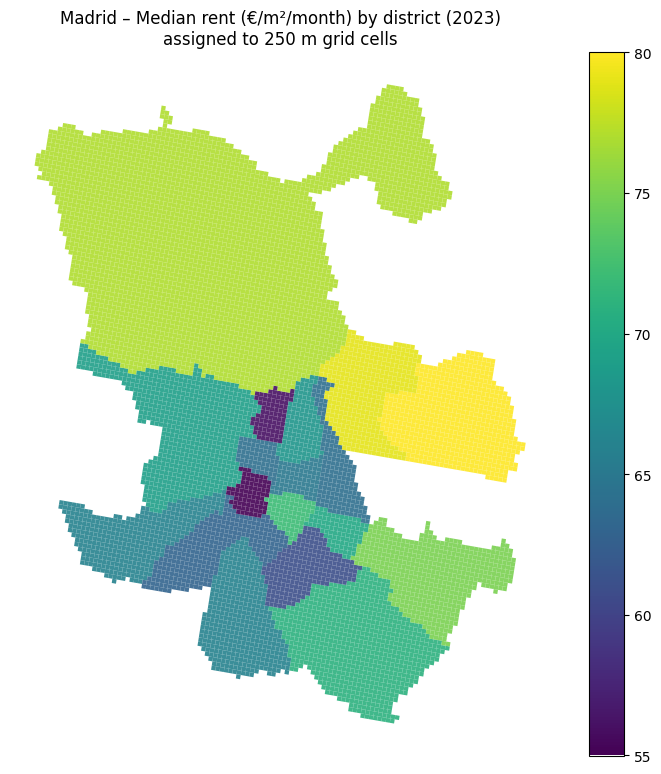

In [341]:
# Quick visualization of rent distribution
fig, ax = plt.subplots(figsize=(8, 8))

grid.plot(
    ax=ax,
    column="rent_median_m2_2023",
    legend=True,
    linewidth=0,
    alpha=0.9
)

ax.set_axis_off()
ax.set_title("Madrid – Median rent (€/m²/month) by district (2023)\nassigned to 250 m grid cells")
plt.tight_layout()
plt.show()

In [342]:
# Save the grid with height + land-use + public transport information + rent stats
out_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport_rent.gpkg")
grid.to_file(out_path, layer="grid_250m_lu_height_transport_rent", driver="GPKG")

print("Saved:", out_path)
print("Total grid cells:", len(grid))

Saved: data/processed/madrid_grid_250m_lu_height_transport_rent.gpkg
Total grid cells: 10100


### Add EMVS Public Housing Data

The next data layer is preprocessed and aligned to the grid. Each layer is added independently to preserve transparency about how individual variables contribute to the combined dataset.

The EMVS dataset contains information on public housing units allocated by district in Madrid between 2015 and 2023.

Unlike land use or transport data, EMVS data:

- is aggregated at district level
- reflects policy-driven housing provision, not market dynamics

For this reason, EMVS is included as a contextual equity indicator, complementing rent statistics.

In [343]:
emvs_path = os.path.join(RAW_DIR, "emvs_housing.csv")

emvs = pd.read_csv(
    emvs_path,
    sep=";",          # Spanish CSV format
    encoding="utf-8",
    header=1
)

emvs.head()

,DISTRITOS,TOTAL,REGLAMENTO ADJUDICACION,RESTO PROGRAMAS,Unnamed: 4,Unnamed: 5
0,ARGANZUELA,155,152,3.0,NaN,NaN
1,BARAJAS,380,326,54.0,NaN,NaN
2,CARABANCHEL,746,494,252.0,NaN,NaN
3,CENTRO,428,283,145.0,NaN,NaN
4,CHAMARTIN,3,3,NaN,NaN,NaN


The EMVS table needs to be cleaned first as well.

In [344]:
# Keep relevant columns
emvs_clean = emvs[["DISTRITOS", "TOTAL"]].copy()
emvs_clean = emvs_clean.rename(columns={
    "DISTRITOS": "district_name",
    "TOTAL": "emvs_units_total"
})

# Drop total summary row
emvs_clean = emvs_clean[emvs_clean["district_name"] != "TOTAL"]

# Convert to numeric
emvs_clean["emvs_units_total"] = pd.to_numeric(
    emvs_clean["emvs_units_total"],
    errors="coerce"
)

emvs_clean.head()
print("Rows:", len(emvs_clean))

Rows: 21


To ensure consistency across datasets, I apply the same normalization logic used for rent statistics during the last step.

In [345]:
def normalize(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("utf-8")
    return s.upper().strip()

emvs_clean["district_key"] = emvs_clean["district_name"].apply(normalize)

emvs_clean[["district_name", "district_key", "emvs_units_total"]].head()


,district_name,district_key,emvs_units_total
0,ARGANZUELA,ARGANZUELA,155
1,BARAJAS,BARAJAS,380
2,CARABANCHEL,CARABANCHEL,746
3,CENTRO,CENTRO,428
4,CHAMARTIN,CHAMARTIN,3


As with the rent statistics before, some district names differ slightly between datasets. I apply the same corrections to ensure matching.

In [346]:
emvs_clean["district_key"] = emvs_clean["district_key"].replace({
    "SAN BLAS": "SAN BLAS - CANILLEJAS",
    "VALLECAS VILLA": "VILLA DE VALLECAS",
    "FUENCARRAL": "FUENCARRAL-EL PARDO",
    "MONCLOA": "MONCLOA-ARAVACA"
})

matches = set(emvs_clean["district_key"]) & set(districts["district_key"])
print("Matching EMVS districts:", len(matches), "of", len(emvs_clean))

missing = sorted(set(emvs_clean["district_key"]) - set(districts["district_key"]))
print("EMVS districts not found in OSM:", missing)


Matching EMVS districts: 21 of 21
EMVS districts not found in OSM: []


Now I join the data so each district polygon contains the total number of public housing units allocated by EMVS.

In [347]:
districts_emvs = districts.merge(
    emvs_clean[["district_key", "emvs_units_total"]],
    on="district_key",
    how="left"
)

districts_emvs[["name", "emvs_units_total"]].head()

,name,emvs_units_total
0,Usera,367
1,Villaverde,934
2,Villa de Vallecas,1252
3,Puente de Vallecas,1252
4,Moratalaz,27


I assign district-level EMVS values to grid cells using a centroid-based spatial join again.

In [348]:
# Load grid with previous indicators
grid_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport_rent.gpkg")
grid = gpd.read_file(grid_path, layer="grid_250m_lu_height_transport_rent")

# Reproject districts to match grid CRS
districts_emvs = districts_emvs.to_crs(grid.crs)

# Create centroids
grid_centroids = grid.copy()
grid_centroids["geometry"] = grid_centroids.geometry.centroid

# Spatial join
grid_emvs = gpd.sjoin(
    grid_centroids[["cell_id", "geometry"]],
    districts_emvs[["emvs_units_total", "geometry"]],
    how="left",
    predicate="within"
)

# Merge back to grid
grid = grid.merge(
    grid_emvs[["cell_id", "emvs_units_total"]],
    on="cell_id",
    how="left"
)

grid["emvs_units_total"].describe()

count    9667.000000
mean      254.820006
std       407.810302
min         2.000000
25%        23.000000
50%        23.000000
75%       367.000000
max      1252.000000
Name: emvs_units_total, dtype: float64

Each grid cell now contains a district-level public housing indicator:

- values represent policy intervention intensity, not density
- sharp district boundaries are expected

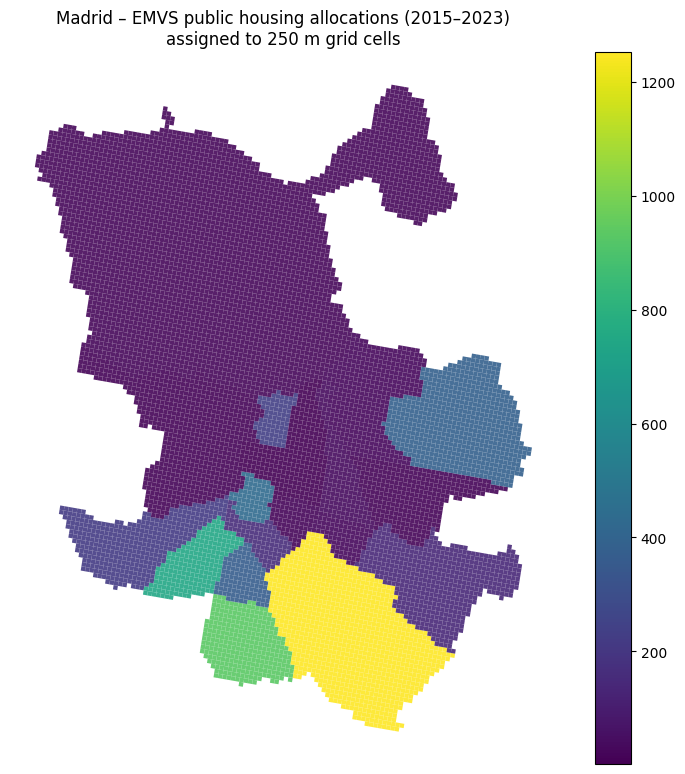

In [349]:
# Quick visualization of the EMVS distribution
fig, ax = plt.subplots(figsize=(8, 8))

grid.plot(
    ax=ax,
    column="emvs_units_total",
    legend=True,
    linewidth=0,
    alpha=0.9
)

ax.set_axis_off()
ax.set_title("Madrid – EMVS public housing allocations (2015–2023)\nassigned to 250 m grid cells")
plt.tight_layout()
plt.show()

In [350]:
# Save the grid with height + land-use + public transport information + rent stats + public housing information
out_path = os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport_rent_emvs.gpkg")
grid.to_file(out_path, layer="grid_250m_lu_height_transport_rent_emvs", driver="GPKG")

print("Saved:", out_path)
print("Total grid cells:", len(grid))

Saved: data/processed/madrid_grid_250m_lu_height_transport_rent_emvs.gpkg
Total grid cells: 10100


### Add District Names

This last data layer adds no new information but rather complements the previous layers by adding a readable "label" to each grid cell.

Up to this point, several indicators (land-use, rent, EMVS housing etc.) were assigned to grid cells using district-level data.
However, the grid itself did not explicitly store which district each cell belongs to. In this step, we therefore add the district name as an attribute to every 250 m grid cell.

In [351]:
# Load EMVS data
emvs_path = os.path.join(RAW_DIR, "emvs_housing.csv")
emvs = pd.read_csv(
    emvs_path,
    sep=";",          # Spanish CSV format
    encoding="utf-8",
    header=1
)

# Clean EMVS data
emvs_clean = emvs.iloc[:-1].copy() # Drop total summary row
emvs_clean = emvs_clean.rename(columns={
    "DISTRITOS": "district_key",
    "TOTAL": "emvs_units_total"
})
emvs_clean["emvs_units_total"] = pd.to_numeric(
    emvs_clean["emvs_units_total"],
    errors="coerce"
)
emvs_clean["district_key"] = emvs_clean["district_key"].str.upper().str.strip()

# Load districts (assuming 'districts' is already defined, as it's used for other joins)
# If 'districts' is not defined, you'll need to load it here.
# For example: districts = gpd.read_file(os.path.join(PROC_DIR, "madrid_districts.gpkg"))

# Merge EMVS data with districts
districts_emvs = districts.merge(
    emvs_clean[['district_key', 'emvs_units_total']],
    on="district_key",
    how="left"
)

# Reproject districts_emvs to match grid CRS
districts_emvs = districts_emvs.to_crs(grid.crs)

# Create centroids for districts_emvs to represent EMVS points for spatial joining
emvs_points = districts_emvs.copy()
emvs_points['geometry'] = emvs_points.geometry.centroid
emvs_points = emvs_points[['emvs_units_total', 'geometry']].to_crs(grid.crs)

# emvs_joined MUST be the sjoin result (points → grid)
emvs_joined = gpd.sjoin(
    emvs_points,
    grid[['cell_id', 'geometry']],
    how="left",
    predicate="within"
)

emvs_agg = (
    emvs_joined
    .groupby("cell_id")["emvs_units_total"]
    .sum()
    .rename("emvs_units_total")
)

grid = grid.drop(columns=["emvs_units_total"], errors="ignore")
grid = grid.drop_duplicates(subset=['cell_id'], keep='first') # Ensure unique cell_id before merge
assert len(grid) == grid["cell_id"].nunique(), "❌ GRID HAS DUPLICATE CELL_ID BEFORE EMVS MERGE"
grid = grid.merge(right=emvs_agg, on="cell_id", how="left")
grid["emvs_units_total"] = grid["emvs_units_total"].fillna(0)

grid = grid.drop(columns=["emvs_units_total"], errors="ignore")
grid = grid.merge(emvs_agg, on="cell_id", how="left")
grid["emvs_units_total"] = grid["emvs_units_total"].fillna(0)

# Sanity check
assert len(grid) == grid["cell_id"].nunique()
print("After EMVS join:", len(grid))

After EMVS join: 10100


In [352]:
# Load data
gdf = gpd.read_file(
    os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport_rent_emvs.gpkg"),
    layer="grid_250m_lu_height_transport_rent_emvs"
)

Make sure that districts are in the same  CRS again.

In [353]:
districts = districts.to_crs(gdf.crs)

I then use centroids to avoid ambiguity at cell edges and keep it consistent with earlier steps.

In [354]:
# Create centroids
gdf_centroids = gdf.copy()
gdf_centroids["geometry"] = gdf_centroids.geometry.centroid

# Spatial join: add district name
gdf_district = gpd.sjoin(
    gdf_centroids[["cell_id", "geometry"]],
    districts[["name", "district_key", "geometry"]],
    how="left",
    predicate="within"
)

# Ensure unique cell_id before merge
gdf_district = gdf_district.drop_duplicates(subset=['cell_id'], keep='first') 

# Merge district name back to grid
gdf = gdf.merge(
    gdf_district[["cell_id", "name"]],
    on="cell_id",
    how="left"
)

# Rename for clarity
gdf = gdf.rename(columns={"name": "district_name"})

gdf[["cell_id", "district_name"]].head()

,cell_id,district_name
0,0,NaN
1,1,Fuencarral-El Pardo
2,2,Fuencarral-El Pardo
3,3,Fuencarral-El Pardo
4,4,NaN


In [355]:
# Save the grid with height + land-use + public transport information + rent stats + public housing information + district names
out_path = os.path.join(
    PROC_DIR,
    "madrid_grid_250m_lu_height_transport_rent_emvs_district.gpkg"
)

gdf.to_file(
    out_path,
    layer="grid_250m_lu_height_transport_rent_emvs_district",
    driver="GPKG"
)

print("Saved with district labels:", out_path)

Saved with district labels: data/processed/madrid_grid_250m_lu_height_transport_rent_emvs_district.gpkg


### Conclusion and Reflection

This EDA resulted in a combined, grid-based dataset that integrates multiple urban data layers into a shared spatial framework. The iterative construction process made it possible to examine spatial patterns, overlaps, and inconsistencies across datasets, while maintaining transparency about the preprocessing and aggregation steps involved. As such, the dataset provides a structured basis for further exploratory analyses and for identifying areas of interest for further investigation.

At the same time, several limitations emerge from the chosen abstractions: 

- Assigning a dominant land-use category to each grid cell simplifies heterogeneous urban areas and may obscure mixed-use conditions. 
- Averaging building heights at a 250 m resolution can dilute the presence of individual tall buildings unless they occur in clusters, affecting the interpretation of vertical density.
- Public housing data reflect sharp administrative boundaries at the district level, which may overemphasize spatial discontinuities that do not necessarily correspond to lived urban experience.

These limitations do not represent errors but structural consequences of the data sources and methodological choices made. They highlight how spatial resolution, aggregation strategies, and data availability shape what becomes visible in data-driven urban analysis, and they inform how the dataset can be interpreted or also extended in subsequent analytical steps.

# Example: Work with the created Combined Dataset

In [356]:
# Load data
gdf = gpd.read_file(
    os.path.join(PROC_DIR, "madrid_grid_250m_lu_height_transport_rent_emvs_district.gpkg"),
    layer="grid_250m_lu_height_transport_rent_emvs_district"
)

gdf.head()

,cell_id,lu_2018_code,lu_2018_class,lu_2018_class_simplified,height_mean,height_max,pt_stop_count,pt_access_good,rent_median_m2_2023,emvs_units_total,district_name,geometry
0,0,11220,Discontinuous medium density urban fabric (S.L. : 30% - 50%),Other,5.875,8.0,0,False,NaN,NaN,None,"POLYGON ((3146886.577 2048808.169, 3146925.861 2049054.547, 3146678.935 2049..."
1,1,23000,Pastures,Pastures,5.000,5.0,0,False,77.0,23.0,Fuencarral-El Pardo,"POLYGON ((3146925.861 2049054.547, 3146965.146 2049300.926, 3146718.22 20493..."
2,2,23000,Pastures,Pastures,NaN,NaN,0,False,77.0,23.0,Fuencarral-El Pardo,"POLYGON ((3146965.146 2049300.926, 3147004.432 2049547.305, 3146757.507 2049..."
3,3,23000,Pastures,Pastures,NaN,NaN,0,False,77.0,23.0,Fuencarral-El Pardo,"POLYGON ((3147004.432 2049547.305, 3147043.72 2049793.684, 3146796.795 20498..."
4,4,11210,Discontinuous dense urban fabric (S.L. : 50% - 80%),Discontinuous dense urban fabric (S.L. : 50% - 80%),NaN,NaN,0,False,NaN,NaN,None,"POLYGON ((3147043.72 2049793.684, 3147083.008 2050040.064, 3146836.084 20500..."


In [357]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   cell_id                   10100 non-null  int64   
 1   lu_2018_code              10100 non-null  object  
 2   lu_2018_class             10100 non-null  object  
 3   lu_2018_class_simplified  10100 non-null  object  
 4   height_mean               4511 non-null   float64 
 5   height_max                4511 non-null   float64 
 6   pt_stop_count             10100 non-null  int64   
 7   pt_access_good            10100 non-null  bool    
 8   rent_median_m2_2023       9313 non-null   float64 
 9   emvs_units_total          9667 non-null   float64 
 10  district_name             9667 non-null   object  
 11  geometry                  10100 non-null  geometry
dtypes: bool(1), float64(4), geometry(1), int64(2), object(4)
memory usage: 878.0+ KB


In [358]:
gdf.describe()

,cell_id,height_mean,height_max,pt_stop_count,rent_median_m2_2023,emvs_units_total
count,10100.000000,4511.000000,4511.000000,10100.000000,9313.000000,9667.000000
mean,5049.500000,13.112925,25.951230,1.210396,72.984001,254.820006
std,2915.763193,7.309244,16.489917,3.300597,5.852833,407.810302
min,0.000000,3.000000,3.000000,0.000000,55.000000,2.000000
25%,2524.750000,7.834388,14.000000,0.000000,69.000000,23.000000
50%,5049.500000,11.690751,24.000000,0.000000,77.000000,23.000000
75%,7574.250000,16.915679,34.000000,0.000000,77.000000,367.000000
max,10099.000000,236.828571,250.000000,70.000000,80.000000,1252.000000


In [246]:
gdf["district_name"].value_counts().head(10)

district_name
Fuencarral-El Pardo      3806
Villa de Vallecas         820
Moncloa-Aravaca           750
Barajas                   681
Vicálvaro                 560
Hortaleza                 431
Latina                    409
San Blas - Canillejas     354
Villaverde                321
Puente de Vallecas        239
Name: count, dtype: int64

In [247]:
gdf["cell_id"].value_counts().head(5)

cell_id
0       1
6737    1
6730    1
6731    1
6732    1
Name: count, dtype: int64

Here is one example how the data can be used now. Since I kept the `geometry` column and use geopandas instead of "normal" pandas, every cell can be displayed with its real-world boundaries and location in Madrid. Therefore a distruict and its respective cells can be displayed easily as an output:

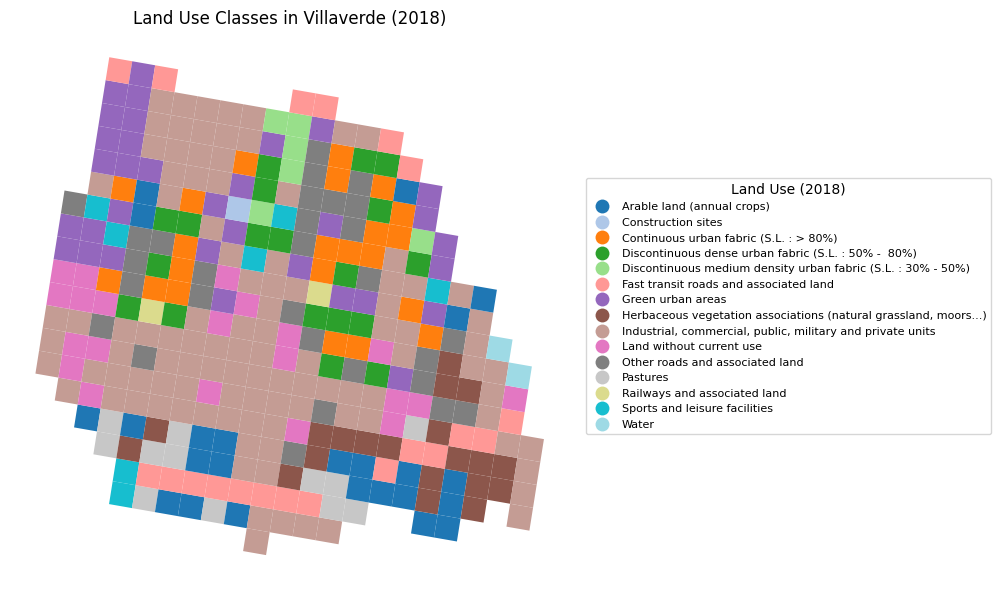

In [359]:
# Filter rows for Villaverde
villaverde = gdf[gdf["district_name"] == "Villaverde"]

fig, ax = plt.subplots(figsize=(9, 6))

villaverde.plot(
    column="lu_2018_class",
    categorical=True,
    cmap="tab20",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5),
        "title": "Land Use (2018)",
        "fontsize": 8
    }
)

ax.set_title("Land Use Classes in Villaverde (2018)")
ax.axis("off")
plt.tight_layout()
plt.show()